# Part 3: Application to Medical Diagnosis

In this final part, we apply a Convolutional Neural Network (CNN) for the binary classification of breast tumors using the CBIS-DDSM database.

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Configuration and Parameters
Here we define the global parameters (training hyperparameters, data paths).

In [2]:
class Config:
    # Paths pointing to the CBIS-DDSM CSV files
    CSV_PATH_TRAIN = "images/archive/csv/mass_case_description_train_set.csv"
    CSV_PATH_TEST = "images/archive/csv/mass_case_description_test_set.csv"
    IMAGE_DIR = "images/archive/" # Root folder containing the 'jpeg' subfolder
    IMAGE_SIZE = 128      # Downsized to avoid RAM saturation (e.g., 128x128 or 224x224)
    BATCH_SIZE = 32
    EPOCHS = 20
    LEARNING_RATE = 1e-4
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
print(f"Device used: {Config.DEVICE}")

Device used: cpu


## 2. Dataset Preparation and Preprocessing

We associate each image with its label from the CSV file.
The `BENIGN` and `BENIGN_WITHOUT_CALLBACK` classes are merged into `0`.
The `MALIGNANT` cases are labeled as `1`.

**Note**: We are using the Kaggle JPEG version of the CBIS-DDSM dataset. The images are stored in subfolders named after their `SeriesInstanceUID`. We extract this UID from the original `.dcm` path in the CSV to find the correct `.jpg` file.

In [3]:
class CBISDDSMDataset(Dataset):
    def __init__(self, csv_file, image_dir):
        self.data = pd.read_csv(csv_file)
        self.image_dir = image_dir
        
        # Mapping classes to binary labels
        self.data['label'] = self.data['pathology'].apply(
            lambda x: 1 if x.strip().upper() == 'MALIGNANT' else 0
        )
        
        self.image_paths = self.data['image file path'].values
        self.labels = self.data['label'].values
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        try:
            # Extract SeriesInstanceUID from the original DICOM path in the CSV
            # Example: Mass-Training_.../.../1.3.6.1.4.1.9590.../000000.dcm
            # The SeriesInstanceUID is the 3rd element when splitting by '/'
            series_uid = self.image_paths[idx].strip().split('/')[2]
            folder_path = os.path.join(self.image_dir, "jpeg", series_uid)
            
            # Find the actual .jpg file inside the folder
            jpg_files = glob.glob(os.path.join(folder_path, "*.jpg"))
            if len(jpg_files) == 0:
                raise FileNotFoundError(f"No JPG found in {folder_path}")
                
            img_path = jpg_files[0].replace("\\", "/")
            
            # Read the JPG image
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if image is None:
                raise ValueError(f"cv2 failed to read {img_path}")
            
            # Normalization [0, 1]
            image = image.astype(np.float32) / 255.0
                
            # Resizing
            image = cv2.resize(image, (Config.IMAGE_SIZE, Config.IMAGE_SIZE))
        except Exception as e:
            # Fallback if image is missing or corrupted (outputs a black square)
            # print(f"Error with image {self.image_paths[idx]}: {e}") # Uncomment to debug
            image = np.zeros((Config.IMAGE_SIZE, Config.IMAGE_SIZE), dtype=np.float32)
            
        # PyTorch dimensions (Channels, H, W)
        image = np.expand_dims(image, axis=0)
        
        return torch.tensor(image, dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.float32)

In [4]:
def show_samples(dataset, num_samples=5):
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))
    benign_idx = np.where(dataset.labels == 0)[0][:num_samples]
    malign_idx = np.where(dataset.labels == 1)[0][:num_samples]
    
    for i, idx in enumerate(benign_idx):
        img, label = dataset[idx]
        axes[0, i].imshow(img[0].numpy(), cmap='gray')
        axes[0, i].set_title("Benign (0)")
        axes[0, i].axis('off')
        
    for i, idx in enumerate(malign_idx):
        img, label = dataset[idx]
        axes[1, i].imshow(img[0].numpy(), cmap='gray')
        axes[1, i].set_title("Malignant (1)", color='red')
        axes[1, i].axis('off')
        
    plt.suptitle("Sample CBIS-DDSM Images (Kaggle JPEG)", fontsize=16)
    plt.tight_layout()
    plt.show()

## 3. Network Architecture (CNN)
A simple CNN comprising convolutional layers followed by MaxPooling, and fully connected classification layers.

In [5]:
class BreastCancerCNN(nn.Module):
    def __init__(self):
        super(BreastCancerCNN, self).__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Calculating the output size after 3 MaxPools (image size divided by 8)
        feature_map_size = Config.IMAGE_SIZE // 8
        flattened_size = 128 * feature_map_size * feature_map_size
        
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 256),
            nn.ReLU(),
            nn.Dropout(0.5), # Regularization
            nn.Linear(256, 1) # A single neuron (logits for binary probability)
        )
        
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

## 4. Training and Evaluation Functions

In [6]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=Config.EPOCHS):
    model.to(Config.DEVICE)
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(Config.DEVICE), labels.to(Config.DEVICE)
            
            optimizer.zero_grad()
            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        
        # Validation
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(Config.DEVICE), labels.to(Config.DEVICE)
                outputs = model(images).squeeze()
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                
                # Binary prediction with a 0.5 threshold
                predicted = (torch.sigmoid(outputs) > 0.5).float()
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        val_loss = val_loss / len(val_loader.dataset)
        val_acc = correct / total
        
        history['train_loss'].append(epoch_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch [{epoch+1:02d}/{epochs}] - Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        
    return history

def evaluate_model(model, test_loader):
    model.to(Config.DEVICE)
    model.eval()
    
    all_labels, all_preds, all_images = [], [], []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images_device = images.to(Config.DEVICE)
            outputs = model(images_device).squeeze()
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            
            all_labels.extend(labels.numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_images.extend(images.numpy())
            
    # Compute global metrics
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    
    print("\n==============================")
    print("      MODEL PERFORMANCE")
    print("==============================")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print("\n--- Detailed Report ---")
    print(classification_report(all_labels, all_preds, target_names=["Benign (0)", "Malignant (1)"], zero_division=0))
    
    # Generate Confusion Matrix Heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=["Benign (0)", "Malignant (1)"], 
                yticklabels=["Benign (0)", "Malignant (1)"])
    plt.xlabel('Model Predictions')
    plt.ylabel('Clinical Reality (True Labels)')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()
    
    return np.array(all_labels), np.array(all_preds), np.array(all_images)

## 5. Main Pipeline

Loading the train set and test set separately, relying on the two CSV files.

Loading Train and Test data...


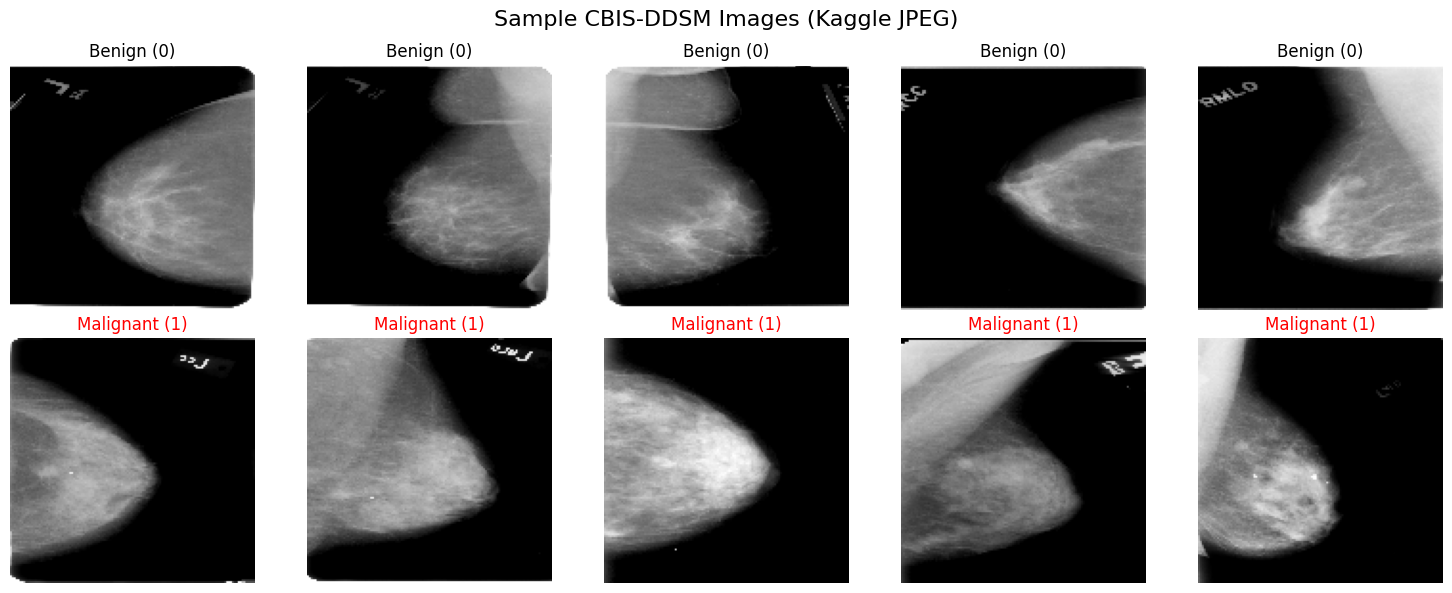

Imbalance detected: 545 Benign vs 509 Malignant.
Corrective weight applied to the 'Malignant' class via pos_weight: 1.07

Starting training...
Epoch [01/20] - Train Loss: 0.8127 | Val Loss: 0.6963 | Val Acc: 0.6098
Epoch [02/20] - Train Loss: 0.6708 | Val Loss: 0.6798 | Val Acc: 0.6174
Epoch [03/20] - Train Loss: 0.6221 | Val Loss: 0.6758 | Val Acc: 0.6136
Epoch [04/20] - Train Loss: 0.5938 | Val Loss: 0.6402 | Val Acc: 0.6818
Epoch [05/20] - Train Loss: 0.5582 | Val Loss: 0.6536 | Val Acc: 0.6553
Epoch [06/20] - Train Loss: 0.5328 | Val Loss: 0.6246 | Val Acc: 0.6591
Epoch [07/20] - Train Loss: 0.4909 | Val Loss: 0.6254 | Val Acc: 0.6667
Epoch [08/20] - Train Loss: 0.4456 | Val Loss: 0.6517 | Val Acc: 0.6932
Epoch [09/20] - Train Loss: 0.4365 | Val Loss: 0.6383 | Val Acc: 0.6629
Epoch [10/20] - Train Loss: 0.4191 | Val Loss: 0.6438 | Val Acc: 0.6970
Epoch [11/20] - Train Loss: 0.3728 | Val Loss: 0.6510 | Val Acc: 0.6667
Epoch [12/20] - Train Loss: 0.3410 | Val Loss: 0.6364 | Val Acc: 

In [ ]:
if not os.path.exists(Config.CSV_PATH_TRAIN) or not os.path.exists(Config.CSV_PATH_TEST):
    print(f"[WARNING] CSV files not found. Check paths in Config.")
else:
    print("Loading Train and Test data...")
    train_val_dataset = CBISDDSMDataset(csv_file=Config.CSV_PATH_TRAIN, image_dir=Config.IMAGE_DIR)
    test_dataset = CBISDDSMDataset(csv_file=Config.CSV_PATH_TEST, image_dir=Config.IMAGE_DIR)
    
    # Show a preview of the images once loaded
    show_samples(train_val_dataset)
    
    # Split the Train dataset into Train (80%) and Validation (20%)
    indices = list(range(len(train_val_dataset)))
    train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=train_val_dataset.labels)
    
    train_dataset = torch.utils.data.Subset(train_val_dataset, train_idx)
    val_dataset = torch.utils.data.Subset(train_val_dataset, val_idx)
    
    train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)
    
    # --- Class Imbalance Management ---
    train_labels = train_val_dataset.labels[train_idx]
    num_neg = np.sum(train_labels == 0)
    num_pos = np.sum(train_labels == 1)
    
    pos_weight_val = num_neg / num_pos if num_pos > 0 else 1.0
    pos_weight = torch.tensor([pos_weight_val]).to(Config.DEVICE)
    print(f"Imbalance detected: {num_neg} Benign vs {num_pos} Malignant.")
    print(f"Corrective weight applied to the 'Malignant' class via pos_weight: {pos_weight_val:.2f}\n")
    
    # Initialization
    model = BreastCancerCNN()
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)
    
    # Training and Evaluation
    print("Starting training...")
    history = train_model(model, train_loader, val_loader, criterion, optimizer)
    
    print("\nFinal evaluation on the Test set...")
    y_true, y_pred, test_imgs = evaluate_model(model, test_loader)

## 6. Graphical Visualizations
Here are the learning curves and the visualization of classification errors on the Test set.

In [ ]:
if 'history' in locals() and 'y_pred' in locals() and 'y_true' in locals():
    # =========================================================
    # GRAPH 1: Learning Curves (Loss & Accuracy)
    # =========================================================
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(range(1, Config.EPOCHS+1), history['train_loss'], label='Train Loss', marker='o')
    plt.plot(range(1, Config.EPOCHS+1), history['val_loss'], label='Val Loss', marker='o')
    plt.title("CNN - Train vs Val Loss")
    plt.xlabel("Epochs"); plt.ylabel("Loss")
    plt.legend(); plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(range(1, Config.EPOCHS+1), history['val_acc'], label='Val Accuracy', marker='o', color='green')
    plt.title("CNN - Validation Accuracy")
    plt.xlabel("Epochs"); plt.ylabel("Accuracy")
    plt.legend(); plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # =========================================================
    # GRAPH 2: Misclassified Images Visualization (Errors)
    # =========================================================
    errors_idx = np.where(y_pred != y_true)[0]
    print(f"\nMLP (Breast Cancer CNN) : {len(errors_idx)} errors out of {len(y_true)} tested images.")
    
    if len(errors_idx) > 0:
        fig, axes = plt.subplots(2, 5, figsize=(15, 6))
        axes = axes.ravel()
        
        for j, idx in enumerate(errors_idx[:10]): 
            axes[j].imshow(test_imgs[idx][0], cmap='gray')
            
            # Color code: Red = False Negative (very severe), Orange = False Positive
            color = 'red' if y_true[idx] == 1 else 'orange'
            true_lbl = "Malignant" if y_true[idx] == 1 else "Benign"
            pred_lbl = "Malignant" if y_pred[idx] == 1 else "Benign"
            
            axes[j].set_title(f"True: {true_lbl}\nPred: {pred_lbl}", fontsize=11, color=color)
            axes[j].axis('off')
            
        for j in range(len(errors_idx), len(axes)):
            axes[j].axis('off')
            
        plt.suptitle("First Misclassified Images (Focusing on False Negatives in Red)", fontsize=14)
        plt.tight_layout()
        plt.show()
else:
    print("Run the training pipeline (previous cell) to generate the graphs.")

## 7. Evaluation and Critical Analysis

### False Negatives Impact Analysis
In the context of a medical diagnosis (oncology), the cost of classification errors is highly asymmetrical. A **false negative** (predicting a lesion as "Benign" when it is actually "Malignant") is the most severe error. It delays the patient's therapeutic care, allowing the tumor to proliferate (potentially with metastasis), which drastically reduces survival chances.

Conversely, a **false positive** (predicting "Malignant" when it is "Benign") will cause anxiety and lead to further examinations (a preventive biopsy), but it does not directly put the patient's life at risk.

Therefore, in a medical model like this one, optimizing global Accuracy is not enough. **The primary objective is to optimize the Recall on the positive class**, meaning to maximize the proportion of malignant cases correctly identified by the model, even if it slightly reduces Precision.

### Technical Improvement Opportunities
To go further than this baseline, here are some possible optimizations:

1. **Threshold Tuning**: The decision threshold is set to 0.5 by default. We could lower it (e.g., 0.3) so that the model classifies the image as "Malignant" at the slightest suspicion, thus maximizing Recall.
2. **Transfer Learning**: Using deep models pre-trained on large datasets (e.g., `ResNet50` or `EfficientNet`) would allow leveraging powerful filters for texture extraction, instead of training the model from scratch.
3. **Medical-Oriented Data Augmentation**: Randomly applying rotations, mirrors (horizontal/vertical flips), or brightness changes during training to increase data diversity and limit overfitting.
4. **Segmentation (RoI - Region of Interest)**: Whole breast images are very large and the tumor often occupies a tiny part of the image. The DDSM dataset provides masks to isolate abnormalities. Training the model only on patches cropped around the tumors would drastically facilitate classification compared to the full image.